In [1]:
import pandas as pd
from modelens import RegressionAnalyzer, regression_models

In [2]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [3]:
raw_data = pd.read_csv("dataset.csv")
df = raw_data.copy()

In [4]:
raw_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
analyzer = RegressionAnalyzer(df=df, target="cnt")

In [6]:
analyzer.info()

In [7]:
target = "cnt"
drop_columns = ["casual", "registered", "dteday", "instant"]

for column in drop_columns:
    df = df.drop(columns=[column])

X = df.drop(columns=[target])
y = df[target]
features = df.columns.drop([target])

In [20]:
analyzer.reinit(df=df,target=target)

#### Comaring Models

In [8]:
models = regression_models()

# analyzer.compare_models(
#     models=models,
#     features=features,
#     export_html=True,
#     file_name="01-base-model-comparing",
# )

In [9]:
selected_models = regression_models(
    smodels=[
        "CatBoost",
        "Gradient Boosting",
        "LightGBM",
    ]
)


# analyzer.compare_models(
#     models=selected_models,
#     features=features,
#     export_html=True,
#     file_name="02-selected-model",
# )

In [10]:
param_grids = {
    "CatBoost": {
        "iterations": [300, 500, 1000],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "l2_leaf_reg": [1, 3, 5],
    },
    "LightGBM": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.03, 0.1],
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 10],
        "min_child_samples": [10, 20],
        "colsample_bytree": [0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 5],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2, 4],
    },
}

# for name, model in selected_models.items():

#     analyzer.tune_model(
#         model=model,
#         features=features,
#         param_grid=param_grids[name],
#         export_html=True,
#         file_name=f"{name.lower().replace(' ', '-')}",
#     )

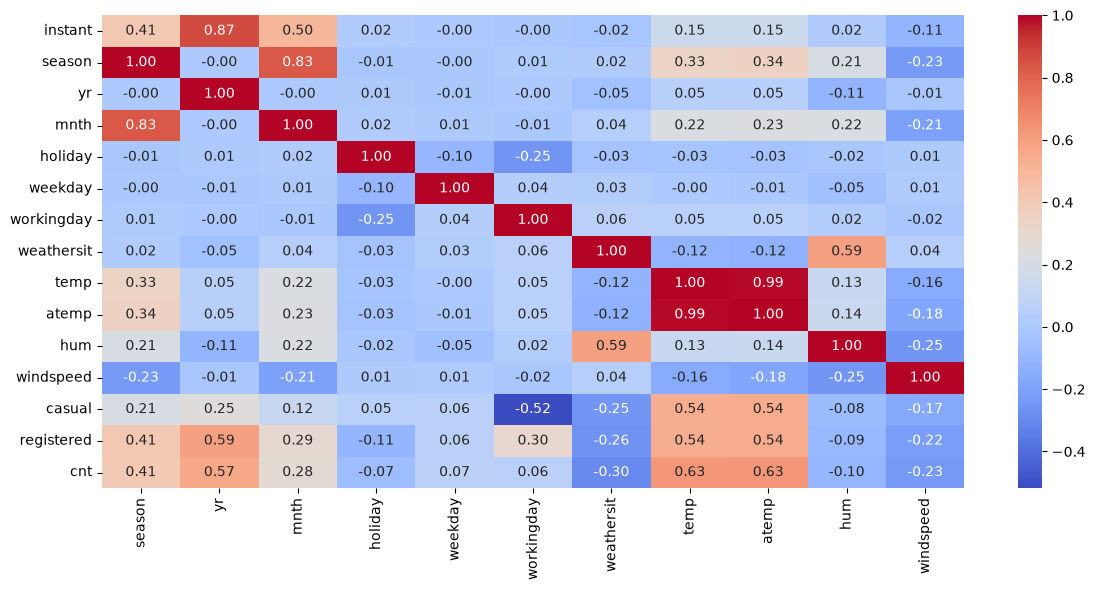

In [11]:
_, suspicious_features = analyzer.correlation(features=features)

In [12]:
analyzer.vif(features=features)

,Feature,VIF
8,atemp,64.343361
7,temp,63.321299
0,season,3.548413
2,mnth,3.333672
9,hum,1.918309
6,weathersit,1.748741
10,windspeed,1.199259
3,holiday,1.083126
5,workingday,1.076392
4,weekday,1.024076


In [13]:
from lightgbm import LGBMRegressor

selected_models["LightGBM"] = LGBMRegressor(
    colsample_bytree=0.8,
    max_depth=10,
    min_child_samples=10,
    learning_rate=0.1,
    n_estimators=100,
    num_leaves=15,
)

In [14]:
# for name, model in selected_models.items():
#     analyzer.evaluate_single_feature_removal(
#         model=model,
#         features=features,
#         export_html=True,
#         file_name=f"{name.lower().replace(' ', '-')}",
#     )

In [15]:
selected_model = models["LightGBM"]

In [16]:
# analyzer.evaluate_feature_removal_combinations(
#     model=selected_model,
#     features=features,
#     candidates=features,
#     export_html=True,
#     file_name=f"{name.lower().replace(' ', '-')}")

In [17]:
selected_features =  ['season', 'yr', 'mnth', 'weekday', 'temp', 'hum', 'windspeed']

In [18]:
analyzer.compare_feature_sets(
    model=selected_model,
    feature_sets={
        "All Features": features,
        "Model 'holiday', 'workingday', 'weathersit', 'atemp'": selected_features,
    },
    export_html=True,
    file_name="lighgbm_feature_comparison",
)

'✓ Report generated successfully: html_reports/compare_feature_sets/lighgbm_feature_comparison.html'

In [21]:
analyzer.residual_analysis(model=selected_model,export_html=True)

(     season  yr  mnth  holiday  weekday  workingday  weathersit      temp  \
 703       4   1    12        0        2           1           1  0.475833   
 33        1   0     2        0        4           1           1  0.186957   
 300       4   0    10        0        5           1           2  0.330833   
 456       2   1     4        0        0           0           2  0.425833   
 633       4   1     9        0        2           1           1  0.550000   
 ..      ...  ..   ...      ...      ...         ...         ...       ...   
 70        1   0     3        0        6           0           1  0.329167   
 192       3   0     7        0        2           1           1  0.794167   
 328       4   0    11        0        5           1           1  0.375000   
 165       2   0     6        0        3           1           1  0.626667   
 135       2   0     5        0        1           1           1  0.577500   
 
         atemp       hum  windspeed  Actual    Predicted     R

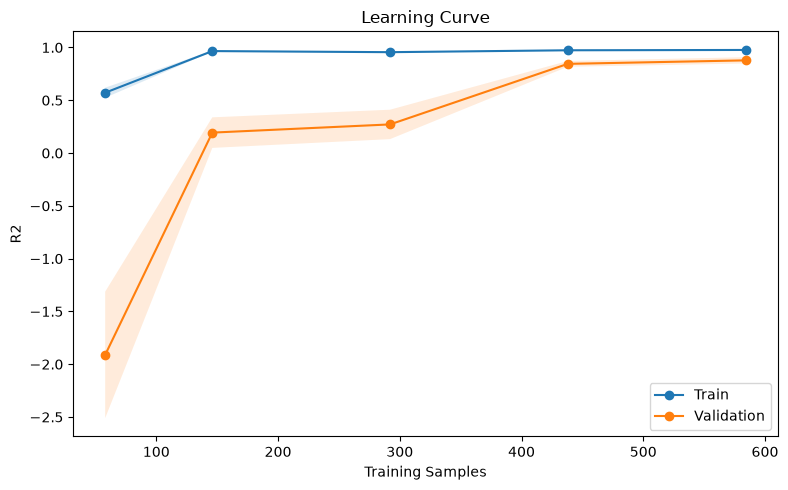

,Train Size,Train R2,Test R2,R2 Gap
0,58,0.5715 ± 0.0475,-1.9114 ± 0.5987,2.482894
1,146,0.9658 ± 0.0048,0.1936 ± 0.1447,0.772188
2,292,0.9554 ± 0.0051,0.2712 ± 0.1392,0.684151
3,438,0.9733 ± 0.0016,0.8447 ± 0.0272,0.128595
4,584,0.9764 ± 0.0020,0.8778 ± 0.0299,0.098538


In [22]:
analyzer.learning_curve(model=selected_model)